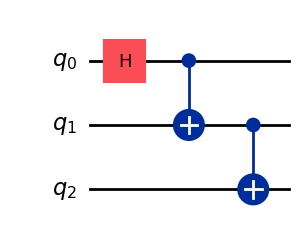

In [7]:
# Create a GHZ state circuit

from qiskit import QuantumCircuit

ghz_circ = QuantumCircuit(3)

ghz_circ.h(0)

ghz_circ.cx(0, 1)
ghz_circ.cx(1, 2)

ghz_circ.draw("mpl")

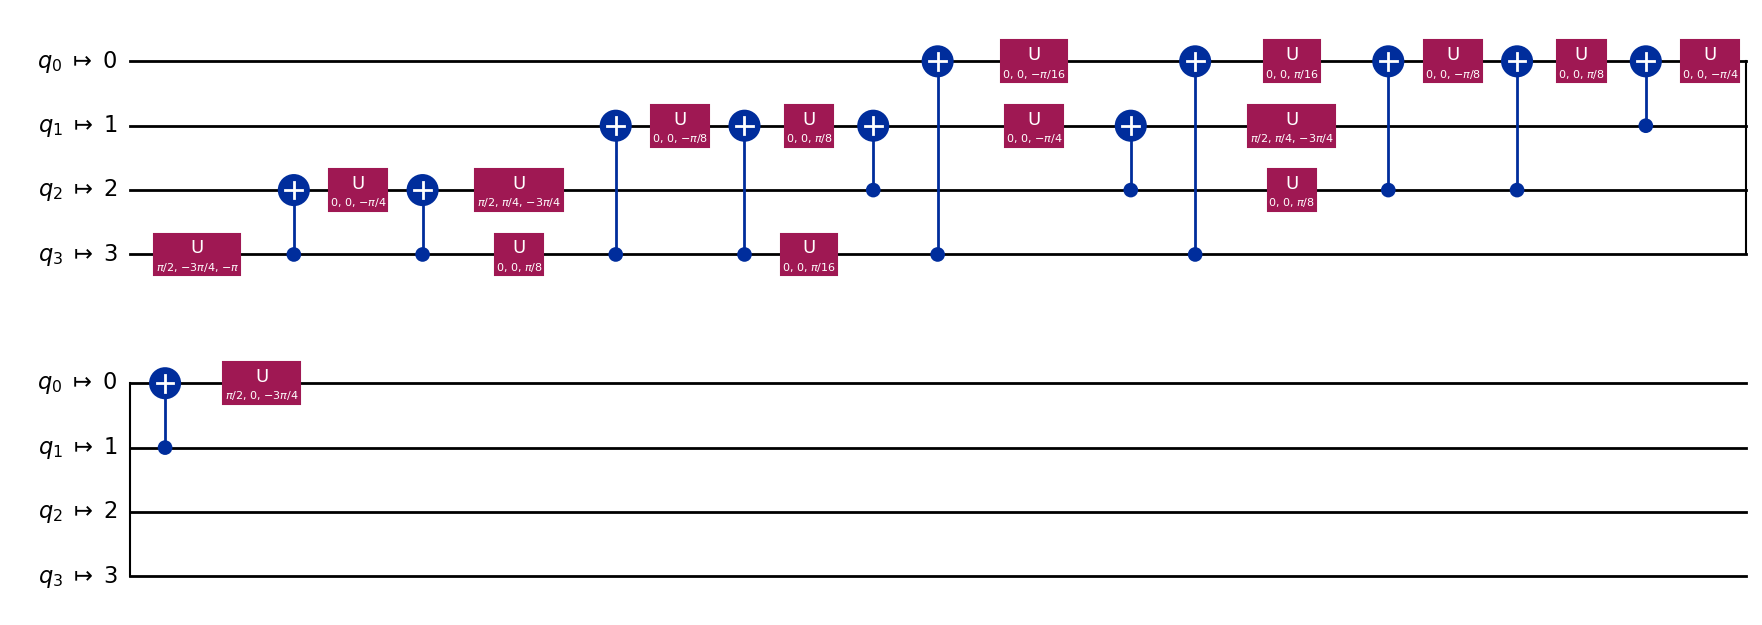

In [4]:
# Creat a QFT circuit

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate

qft_circ = QuantumCircuit(4)
qft_circ.x(3)

qft_circ.append(QFTGate(4), range(4))

# qft_circ.draw('mpl')

# transpile:
t_qft = transpile(qft_circ, basis_gates=["cx", "u"])

# Visualize the transpiled circuit
t_qft.draw("mpl")

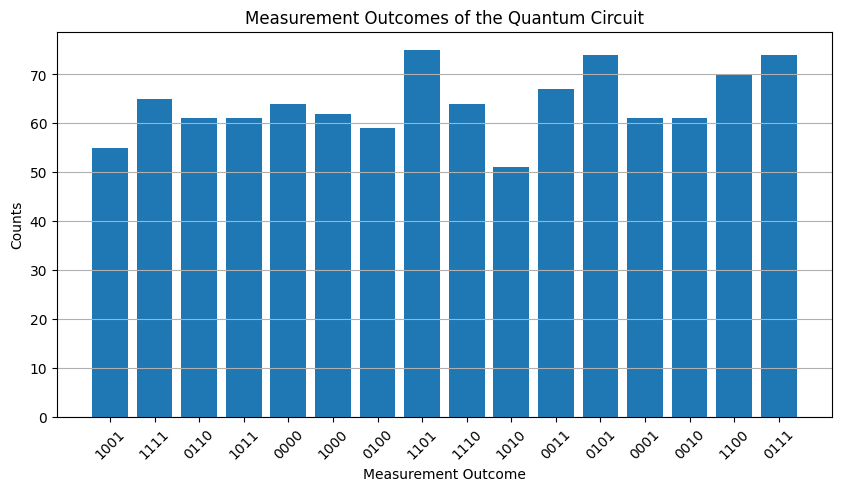

In [9]:
# Aer simulator

import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator

t_qft.measure_all()

simulator = AerSimulator()
compiled_circuit = transpile(t_qft, simulator)

# Run the circuit on the simulator
shots = 1024
result = simulator.run(circuits=compiled_circuit, shots=shots).result()
counts = result.get_counts()

# Plot the results
plt.subplots(figsize=(10, 5))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Measurement Outcome")
plt.ylabel("Counts")
plt.title("Measurement Outcomes of the Quantum Circuit")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

C:\Users\benni\AppData\Local\Temp\ipykernel_8856\3025217320.py:10: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circ_d.append(QFT(4), range(4))


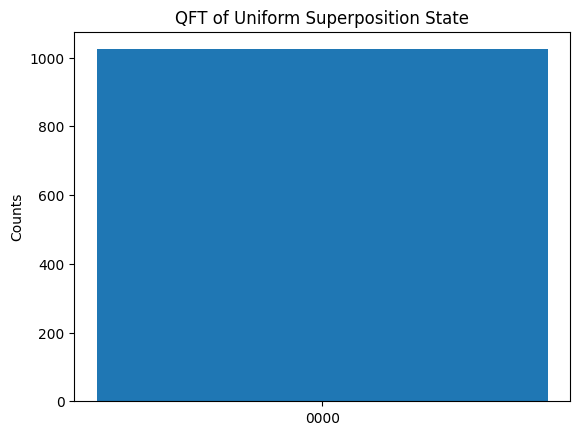

In [10]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator

circ_d = QuantumCircuit(4)

circ_d.h(range(4))

circ_d.append(QFT(4), range(4))

circ_d.measure_all()

simulator = AerSimulator()
compiled_circ_d = transpile(circ_d, simulator, basis_gates=["cx", "u"])

result_d = simulator.run(compiled_circ_d, shots=1024).result()
counts_d = result_d.get_counts()

plt.bar(counts_d.keys(), counts_d.values())
plt.title("QFT of Uniform Superposition State")
plt.ylabel("Counts")
plt.show()

In [ ]:
# test mock simulato
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

from fp_qsim.simulator import MockSimulator

circ = QuantumCircuit(3)
circ.h(0)
circ.cx(0, 1)
circ.cx(1, 2)
circ.measure_all()

my_sim = MockSimulator()

result_counts = my_sim.run(circ, shots=1024)
counts = result_counts.get_counts()  # type: ignore

print("Measurement Counts:", counts)
plot_histogram(counts, title="MockSimulator: Counts")
plt.show()

Measurement Counts: {'111': 494, '000': 530}


In [1]:
import numpy as np

n_qubits = 2
statevector = np.zeros(2**n_qubits, dtype=int)
statevector[0] = 1.0  # |00⟩

# Reshape into tensor form: (2, 2, ..., 2)
psi = statevector.reshape([2] * n_qubits)

# --- Define a Hadamard gate ---
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=int)

# --- Apply H to qubit 0 using einsum ---
# Index notation:
# H[a,b], psi[b,c] -> result[a,c]
psi_einsum = np.einsum("ab,bc->ac", H, psi)

print(psi_einsum)

[[0.70710678 0.        ]
 [0.70710678 0.        ]]
